https://drive.google.com/file/d/1ApuBRdGGp_-Dc8Abkm1n2R7sittx91Yk/view?usp=sharing

#**Team4 - Citi Bike NYC Demand Prediction**
**Course:** BA810 - Supervised Machine Learning  
**Team Members:** Jingyao Wang
, Kefei Zhang
, Yuanhao Li
, Zexuan Wang


## **Table of Contents**

---

---

- Introduction
- Problem Definition
- Motivation
- Data Description
- Data Loading & Cleaning
- Feature Engineering
- Weather Integration
- Final ML Dataset Preparation
- EDA - Phase 1
- Modeling (Baseline Models)
- Hyperparameter Tuning
- Feature Importance
- Final Model Training
- Conclusion
- Recommendation
- Challenges & Limitations
- Generative AI Reference



### **Introduction**

---

---
Citi Bike usage patterns offer a clear lens into how micro-mobility supports both daily commuting and recreational travel in New York City. As a large, citywide bike-share system, Citi Bike serves diverse neighborhoods and functions as a last-mile option and a flexible alternative for short trips. The 2023 dataset shows strong time- and weather-driven demand signals, including commute-hour peaks, weekday–weekend differences, and seasonal shifts linked to temperature and precipitation. These patterns make the system valuable for behavioral and operational analysis, while also highlighting the need for structured forecasting to manage demand volatility efficiently.


### **Problem Definition**

---

---

We forecast Citi Bike demand at the station–hour level using the full 2023 trip dataset. The task is framed as a supervised regression problem, where the target is hourly demand per station, enabling fine-grained predictions for rebalancing and operations.

To model real-world drivers of ridership, we incorporate:

* Temporal patterns — hour, weekday, season

* Short-term continuity — lag and rolling-demand features

* Station effects — location-specific usage differences

* Weather conditions — temperature, precipitation, wind

By combining these signals, our goal is to deliver accurate, interpretable forecasts that improve bike allocation, reduce shortages, and enhance overall system reliability.

### **Motivation**

---

---

**Why this matters**

* Citi Bike operations: Accurate hourly demand forecasting helps decide where bikes need to be, reducing shortages and idle inventory.

* Urban mobility planning: Understanding demand patterns supports sustainable transportation policies and infrastructure decisions.

* Riders and user experience: Better rebalancing can reduce wait times and improve availability during high-demand periods.

**What we aim to learn & how we approach it**

* Identify the factors that shape hourly station-level demand

* Engineer temporal, lagged, and weather-based features to capture short-term dynamics

* Apply supervised learning to characterize and predict demand fluctuations at a fine temporal scale

In summary, this project aims to translate raw trip records into actionable demand forecasts that can help Citi Bike anticipate hourly usage and deploy bikes more effectively. By quantifying how time, location, and weather shape rider behavior, our goal is to provide practical, data-driven insights that directly support operational planning and improves system reliability for users.

### **Data Description**

---

---

Citi Bike Trip Data

- Data Link: Official Citi Bike NYC system data (Lyft) https://citibikenyc.com/system-data

- Data Source:  NYCBS Data Use Policy

- Data Structure: 1 million rows and 13 columns

- Data Origin & Context:
This dataset is officially released by Lyft, the operator of the Citi Bike program. It is derived from real bicycle rental transaction records across New York City, capturing both commuting and recreational usage patterns.

- Collection Period & Context:
2023 New York City bike-sharing data reveals relatively stable short-distance commuting patterns and seasonal trends in high-density urban areas.

NOAA Weather Data

- Data Link:
NOAA Integrated Surface Database (ISD) — https://www.ncei.noaa.gov/products/integrated-surface-database

- Data Source:
National Oceanic and Atmospheric Administration (NOAA), National Centers for Environmental Information (NCEI).

- Data Origin & Context:
The ISD dataset compiles hourly weather observations from global surface stations, including those in New York City. It contains measurements such as temperature, wind speed, and precipitation, recorded by airport and urban monitoring sites. These conditions provide essential environmental context for understanding and predicting Citi Bike demand, as weather strongly influences riding behavior.


### 1.Data Loading & Cleaning

---

---

Load the dataset from Google Drive

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/BA810 project/citibike_2023_sample_1M .csv"

OUTPUT_DIR = "/content/drive/MyDrive/BA810 project/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("File exists:", os.path.exists(DATA_PATH))

File exists: True


In [ ]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print("Raw sample shape:", df_raw.shape)
df_raw.head()

Raw sample shape: (999996, 14)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,month_tag
0,58C51544CF4FD627,classic_bike,2023-01-23 17:26:31.779,2023-01-23 17:31:25.098,Broadway & W 61 St,7014.12,West End Ave & W 60 St,7059.08,40.770030,-73.981968,40.772370,-73.990050,member,202301
1,C11E10BFBE76CCE0,classic_bike,2023-01-28 12:55:21.339,2023-01-28 12:58:05.370,E 16 St & 5 Ave,6022.04,W 15 St & 6 Ave,5989.02,40.737262,-73.992390,40.738046,-73.996430,casual,202301
2,6CA14F8030B7B222,classic_bike,2023-01-04 17:34:54.312,2023-01-04 17:52:53.243,E 59 St & Madison Ave,6801.01,W 87 St & Amsterdam Ave,7458.03,40.763505,-73.971092,40.788390,-73.974700,casual,202301
3,95B7919889C0C07A,classic_bike,2023-01-12 09:36:06.804,2023-01-12 09:49:19.231,Ave D & E 8 St,5506.10,Lafayette St & E 8 St,5788.13,40.723684,-73.975748,40.730207,-73.991026,member,202301
4,6998B58F252E2B5F,electric_bike,2023-01-21 23:10:54.556,2023-01-21 23:15:45.324,Clinton Ave & Myrtle Ave,4651.02,Bergen St & Vanderbilt Ave,4157.10,40.693261,-73.968896,40.679439,-73.968044,member,202301


Quick info and basic checks

In [ ]:
df_raw.info()
print("\nSample of columns:", df_raw.columns.tolist()[:20])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999996 entries, 0 to 999995
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             999996 non-null  object 
 1   rideable_type       999996 non-null  object 
 2   started_at          999996 non-null  object 
 3   ended_at            999996 non-null  object 
 4   start_station_name  999514 non-null  object 
 5   start_station_id    999514 non-null  object 
 6   end_station_name    997090 non-null  object 
 7   end_station_id      997090 non-null  object 
 8   start_lat           999514 non-null  float64
 9   start_lng           999514 non-null  float64
 10  end_lat             997118 non-null  float64
 11  end_lng             997118 non-null  float64
 12  member_casual       999996 non-null  object 
 13  month_tag           999996 non-null  int64  
dtypes: float64(4), int64(1), object(9)
memory usage: 106.8+ MB

Sample of columns: ['rid

Data Cleaning

---

As an initial cleaning step, we trimmed the raw dataset to only the essential fields needed for analysis—timestamps, station information, coordinates, bike type, and rider category. The code also checks for column availability to handle schema variations. This reduces noise, ensures consistency, and provides a clean foundation for EDA and supervised learning.

In [ ]:
columns_to_keep = [
    "ride_id",
    "rideable_type",
    "started_at",
    "ended_at",
    "start_station_name",
    "start_station_id",
    "end_station_name",
    "end_station_id",
    "start_lat",
    "start_lng",
    "end_lat",
    "end_lng",
    "member_casual"
]

# Filter to existing columns only
columns_to_keep = [c for c in columns_to_keep if c in df_raw.columns]

df = df_raw[columns_to_keep].copy()
print("After column selection:", df.shape)
df.head()

After column selection: (999996, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,58C51544CF4FD627,classic_bike,2023-01-23 17:26:31.779,2023-01-23 17:31:25.098,Broadway & W 61 St,7014.12,West End Ave & W 60 St,7059.08,40.770030,-73.981968,40.772370,-73.990050,member
1,C11E10BFBE76CCE0,classic_bike,2023-01-28 12:55:21.339,2023-01-28 12:58:05.370,E 16 St & 5 Ave,6022.04,W 15 St & 6 Ave,5989.02,40.737262,-73.992390,40.738046,-73.996430,casual
2,6CA14F8030B7B222,classic_bike,2023-01-04 17:34:54.312,2023-01-04 17:52:53.243,E 59 St & Madison Ave,6801.01,W 87 St & Amsterdam Ave,7458.03,40.763505,-73.971092,40.788390,-73.974700,casual
3,95B7919889C0C07A,classic_bike,2023-01-12 09:36:06.804,2023-01-12 09:49:19.231,Ave D & E 8 St,5506.10,Lafayette St & E 8 St,5788.13,40.723684,-73.975748,40.730207,-73.991026,member
4,6998B58F252E2B5F,electric_bike,2023-01-21 23:10:54.556,2023-01-21 23:15:45.324,Clinton Ave & Myrtle Ave,4651.02,Bergen St & Vanderbilt Ave,4157.10,40.693261,-73.968896,40.679439,-73.968044,member


In [ ]:
# Drop rows with missing start_station_id
df = df[df["start_station_id"].notna()].copy()
print("After dropping missing start_station_id:", df.shape)

After dropping missing start_station_id: (999514, 13)


In [ ]:
# Parse timestamps
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"]   = pd.to_datetime(df["ended_at"], errors="coerce")

# Drop rows with invalid timestamps
df = df.dropna(subset=["started_at", "ended_at"]).copy()
print("After dropping invalid timestamps:", df.shape)

After dropping invalid timestamps: (999514, 13)


In [ ]:
# Compute trip duration and filter out unrealistic trips
# Duration in minutes
df["trip_duration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60.0

# Keep only trips with duration between 1 and 120 minutes
df = df[(df["trip_duration_min"] >= 1) & (df["trip_duration_min"] <= 120)].copy()
print("After trip duration filtering:", df.shape)

After trip duration filtering: (995788, 14)


In [ ]:
# Ensure station IDs are treated as strings
df["start_station_id"] = df["start_station_id"].astype(str)
df["end_station_id"]   = df["end_station_id"].astype(str)

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_min
0,58C51544CF4FD627,classic_bike,2023-01-23 17:26:31.779,2023-01-23 17:31:25.098,Broadway & W 61 St,7014.12,West End Ave & W 60 St,7059.08,40.770030,-73.981968,40.772370,-73.990050,member,4.888650
1,C11E10BFBE76CCE0,classic_bike,2023-01-28 12:55:21.339,2023-01-28 12:58:05.370,E 16 St & 5 Ave,6022.04,W 15 St & 6 Ave,5989.02,40.737262,-73.992390,40.738046,-73.996430,casual,2.733850
2,6CA14F8030B7B222,classic_bike,2023-01-04 17:34:54.312,2023-01-04 17:52:53.243,E 59 St & Madison Ave,6801.01,W 87 St & Amsterdam Ave,7458.03,40.763505,-73.971092,40.788390,-73.974700,casual,17.982183
3,95B7919889C0C07A,classic_bike,2023-01-12 09:36:06.804,2023-01-12 09:49:19.231,Ave D & E 8 St,5506.10,Lafayette St & E 8 St,5788.13,40.723684,-73.975748,40.730207,-73.991026,member,13.207117
4,6998B58F252E2B5F,electric_bike,2023-01-21 23:10:54.556,2023-01-21 23:15:45.324,Clinton Ave & Myrtle Ave,4651.02,Bergen St & Vanderbilt Ave,4157.10,40.693261,-73.968896,40.679439,-73.968044,member,4.846133


### 2.Feature Engineering

---

---

In this first feature engineering step, we extract key time components from the trip start timestamp (started_at) to capture hourly, weekly, and monthly usage patterns. Specifically, we derive hour, weekday, and month, then map months into four intuitive seasons to reflect broader weather and lifestyle, driven demand shifts. We also create an hour-level timestamp (hour_ts) by flooring started_at to the nearest hour, which provides a consistent time index for aggregating rides at the station-hour level.

In [ ]:
# Extract time components from started_at
df["hour"]    = df["started_at"].dt.hour       # 0-23
df["weekday"] = df["started_at"].dt.weekday       # Monday=0, Sunday=6
df["month"]   = df["started_at"].dt.month       # 1–12

In [ ]:
# Derive season from month
def get_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "fall"

df["season"] = df["month"].apply(get_season)
df["season"].value_counts()

,count
season,
winter,249160
spring,249023
summer,248838
fall,248767


In [ ]:
# Create hour-level timestamp for aggregation
# aggregate all trips at the station-hour level.
df["hour_ts"] = df["started_at"].dt.floor("H")
df[["started_at", "hour_ts"]].head()

/tmp/ipython-input-1794860427.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour_ts"] = df["started_at"].dt.floor("H")


,started_at,hour_ts
0,2023-01-23 17:26:31.779,2023-01-23 17:00:00
1,2023-01-28 12:55:21.339,2023-01-28 12:00:00
2,2023-01-04 17:34:54.312,2023-01-04 17:00:00
3,2023-01-12 09:36:06.804,2023-01-12 09:00:00
4,2023-01-21 23:10:54.556,2023-01-21 23:00:00


#### 1)Aggregate hourly demand

---


In this step, we aggregate trip records to the station-hour level, where each row represents the total number of rides starting from a given station within a specific hour. We then re-attach key calendar features (hour, weekday, month, season) based on hour_ts to preserve temporal context.

In [ ]:
# Aggregate to station-hour demand
# Each row will represent one station in one hour, with the total number of trips.
agg = (
    df.groupby(["start_station_id", "hour_ts"])
      .size()
      .reset_index(name="demand")
)

print("Hourly aggregated shape:", agg.shape)
agg.head()

Hourly aggregated shape: (887968, 3)


,start_station_id,hour_ts,demand
0,2733.03,2023-01-03 17:00:00,1
1,2733.03,2023-01-06 18:00:00,1
2,2733.03,2023-01-10 22:00:00,1
3,2733.03,2023-01-11 20:00:00,1
4,2733.03,2023-01-17 16:00:00,1


In [ ]:
# Add back calendar features at the hourly level (based on hour_ts)
agg["hour"]    = agg["hour_ts"].dt.hour
agg["weekday"] = agg["hour_ts"].dt.weekday
agg["month"]   = agg["hour_ts"].dt.month

agg["season"] = agg["month"].apply(get_season)
agg.head()

,start_station_id,hour_ts,demand,hour,weekday,month,season
0,2733.03,2023-01-03 17:00:00,1,17,1,1,winter
1,2733.03,2023-01-06 18:00:00,1,18,4,1,winter
2,2733.03,2023-01-10 22:00:00,1,22,1,1,winter
3,2733.03,2023-01-11 20:00:00,1,20,2,1,winter
4,2733.03,2023-01-17 16:00:00,1,16,1,1,winter


Lag features



In this step, we create station-level lag features for hourly demand (1, 2, 3, and 24 hours). By shifting each station’s historical demand values, these features capture short-term continuity and daily seasonality.

In [ ]:
# Create lag features of 1, 2, 3, and 24 hours per station
lag_hours = [1, 2, 3, 24]

agg = agg.sort_values(["start_station_id", "hour_ts"]).copy()

for lag in lag_hours:
    agg[f"lag_{lag}"] = (
        agg.groupby("start_station_id")["demand"]
           .shift(lag)
    )

agg.head(10)

,start_station_id,hour_ts,demand,hour,weekday,month,season,lag_1,lag_2,lag_3,lag_24
0,2733.03,2023-01-03 17:00:00,1,17,1,1,winter,NaN,NaN,NaN,NaN
1,2733.03,2023-01-06 18:00:00,1,18,4,1,winter,1.0,NaN,NaN,NaN
2,2733.03,2023-01-10 22:00:00,1,22,1,1,winter,1.0,1.0,NaN,NaN
3,2733.03,2023-01-11 20:00:00,1,20,2,1,winter,1.0,1.0,1.0,NaN
4,2733.03,2023-01-17 16:00:00,1,16,1,1,winter,1.0,1.0,1.0,NaN
5,2733.03,2023-01-25 07:00:00,1,7,2,1,winter,1.0,1.0,1.0,NaN
6,2733.03,2023-01-25 16:00:00,1,16,2,1,winter,1.0,1.0,1.0,NaN
7,2733.03,2023-01-31 21:00:00,1,21,1,1,winter,1.0,1.0,1.0,NaN
8,2733.03,2023-02-02 21:00:00,1,21,3,2,winter,1.0,1.0,1.0,NaN
9,2733.03,2023-02-06 07:00:00,1,7,0,2,winter,1.0,1.0,1.0,NaN


Rolling window features


In this step, we add rolling window features at the station-hour level to capture short-term trends and variability in demand. We compute the 3-hour and 6-hour moving averages to smooth recent usage patterns, and a 6-hour rolling standard deviation to reflect demand volatility.

In [ ]:
# Create rolling window features (moving averages and volatility)

# Rolling mean over the past 3 hours
agg["rolling_3h_mean"] = (
    agg.groupby("start_station_id")["demand"]
       .rolling(window=3, min_periods=1)
       .mean()
       .reset_index(level=0, drop=True)
)

# Rolling mean over the past 6 hours
agg["rolling_6h_mean"] = (
    agg.groupby("start_station_id")["demand"]
       .rolling(window=6, min_periods=1)
       .mean()
       .reset_index(level=0, drop=True)
)

# Rolling standard deviation over the past 6 hours
agg["rolling_6h_std"] = (
    agg.groupby("start_station_id")["demand"]
       .rolling(window=6, min_periods=2)
       .std()
       .reset_index(level=0, drop=True)
)
agg.head(10)

,start_station_id,hour_ts,demand,hour,weekday,month,season,lag_1,lag_2,lag_3,lag_24,rolling_3h_mean,rolling_6h_mean,rolling_6h_std
0,2733.03,2023-01-03 17:00:00,1,17,1,1,winter,NaN,NaN,NaN,NaN,1.0,1.0,NaN
1,2733.03,2023-01-06 18:00:00,1,18,4,1,winter,1.0,NaN,NaN,NaN,1.0,1.0,0.0
2,2733.03,2023-01-10 22:00:00,1,22,1,1,winter,1.0,1.0,NaN,NaN,1.0,1.0,0.0
3,2733.03,2023-01-11 20:00:00,1,20,2,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0
4,2733.03,2023-01-17 16:00:00,1,16,1,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0
5,2733.03,2023-01-25 07:00:00,1,7,2,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0
6,2733.03,2023-01-25 16:00:00,1,16,2,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0
7,2733.03,2023-01-31 21:00:00,1,21,1,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0
8,2733.03,2023-02-02 21:00:00,1,21,3,2,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0
9,2733.03,2023-02-06 07:00:00,1,7,0,2,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0


#### 2)Station-level features

---

we keep station_popularity as the main station-level feature.

In [ ]:
# Station-level long-term features
# Average demand per station
station_mean_demand = agg.groupby("start_station_id")["demand"].mean()
agg["station_popularity"] = agg["start_station_id"].map(station_mean_demand)

agg.head()

,start_station_id,hour_ts,demand,hour,weekday,month,season,lag_1,lag_2,lag_3,lag_24,rolling_3h_mean,rolling_6h_mean,rolling_6h_std,station_popularity
0,2733.03,2023-01-03 17:00:00,1,17,1,1,winter,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.014706
1,2733.03,2023-01-06 18:00:00,1,18,4,1,winter,1.0,NaN,NaN,NaN,1.0,1.0,0.0,1.014706
2,2733.03,2023-01-10 22:00:00,1,22,1,1,winter,1.0,1.0,NaN,NaN,1.0,1.0,0.0,1.014706
3,2733.03,2023-01-11 20:00:00,1,20,2,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0,1.014706
4,2733.03,2023-01-17 16:00:00,1,16,1,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0,1.014706


#### 3)Cyclic encodings for hour and weekday

---


In [ ]:
# Cyclic encoding for hour and weekday

# Hour of day: 24-hour cycle
agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)

# Weekday: 7-day cycle
agg["weekday_sin"] = np.sin(2 * np.pi * agg["weekday"] / 7)
agg["weekday_cos"] = np.cos(2 * np.pi * agg["weekday"] / 7)

agg.head()

,start_station_id,hour_ts,demand,hour,weekday,month,season,lag_1,lag_2,lag_3,lag_24,rolling_3h_mean,rolling_6h_mean,rolling_6h_std,station_popularity,hour_sin,hour_cos,weekday_sin,weekday_cos
0,2733.03,2023-01-03 17:00:00,1,17,1,1,winter,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.014706,-0.965926,-2.588190e-01,0.781831,0.623490
1,2733.03,2023-01-06 18:00:00,1,18,4,1,winter,1.0,NaN,NaN,NaN,1.0,1.0,0.0,1.014706,-1.000000,-1.836970e-16,-0.433884,-0.900969
2,2733.03,2023-01-10 22:00:00,1,22,1,1,winter,1.0,1.0,NaN,NaN,1.0,1.0,0.0,1.014706,-0.500000,8.660254e-01,0.781831,0.623490
3,2733.03,2023-01-11 20:00:00,1,20,2,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0,1.014706,-0.866025,5.000000e-01,0.974928,-0.222521
4,2733.03,2023-01-17 16:00:00,1,16,1,1,winter,1.0,1.0,1.0,NaN,1.0,1.0,0.0,1.014706,-0.866025,-5.000000e-01,0.781831,0.623490


#### 4)Handle initial NaNs from lag/rolling

---

We want to keep only rows where all main lag features are present.

In [ ]:
# The earliest few hours for each station will not have lag values, so we drop those rows for modeling.
lag_cols = [f"lag_{h}" for h in lag_hours]

agg_clean = agg.dropna(subset=lag_cols).copy()
print("After dropping rows with missing lag features:", agg_clean.shape)
agg_clean.head()

After dropping rows with missing lag features: (837626, 19)


,start_station_id,hour_ts,demand,hour,weekday,month,season,lag_1,lag_2,lag_3,lag_24,rolling_3h_mean,rolling_6h_mean,rolling_6h_std,station_popularity,hour_sin,hour_cos,weekday_sin,weekday_cos
24,2733.03,2023-04-16 13:00:00,1,13,6,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.258819,-9.659258e-01,-0.781831,0.623490
25,2733.03,2023-04-21 13:00:00,1,13,4,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.258819,-9.659258e-01,-0.433884,-0.900969
26,2733.03,2023-04-22 13:00:00,1,13,5,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.258819,-9.659258e-01,-0.974928,-0.222521
27,2733.03,2023-04-27 18:00:00,1,18,3,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-1.000000,-1.836970e-16,0.433884,-0.900969
28,2733.03,2023-05-03 19:00:00,1,19,2,5,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.965926,2.588190e-01,0.974928,-0.222521


#### 5)Weather Integration

---

In this step, we integrate hourly weather conditions from the NOAA dataset into the bikeshare trip data to enrich demand analysis. We first convert the NOAA DATE field to datetime and align it to an hourly timestamp (hour_ts) to match the bikeshare aggregation level. Next, we parse key weather indicators from the raw NOAA fields, extracting temperature from TMP and wind speed from WND, then keep only the relevant hourly columns in a cleaned weather table. After creating a matching hour_ts from started_at, we merge the weather data into the trip dataset. Finally, we convert temperature and wind speed into interpretable units (temp_c, wind_speed_ms), creating standardized weather features that can be used for EDA and modeling to evaluate how climate conditions influence hourly ridership demand.


Load NOAA weather dataset

In [ ]:
import numpy as np
import pandas as pd

WEATHER_PATH = "/content/drive/MyDrive/BA810 project/weather.csv"

weather = pd.read_csv(WEATHER_PATH, low_memory=False)
print("Raw weather shape:", weather.shape)
weather.head()

Raw weather shape: (11842, 91)


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,WND,CIG,VIS,TMP,DEW,SLP,AA1,AA2,AA3,AB1,AD1,AE1,AH1,AH2,AH3,AH4,AH5,AH6,AI1,AI2,AI3,AI4,AI5,AI6,AJ1,AK1,AL1,AM1,AN1,AT1,AT2,AT3,AT4,AT5,AU1,AU2,AW1,AW2,AW3,AX1,AX2,AX3,AX4,GA1,GA2,GA3,GD1,GD2,GD3,GE1,GF1,KA1,KA2,KB1,KB2,KB3,KC1,KC2,KD1,KD2,KE1,KG1,KG2,MA1,MD1,MF1,MG1,MH1,MK1,MW1,OC1,OD1,OE1,OE2,OE3,RH1,RH2,RH3,WA1,REM,EQD
0,72505394728,2023-01-01T00:06:00,7,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",FM-16,KNYC,V030,"999,9,C,0000,5","00152,5,M,N","002414,5,N,5","+0100,5","+0089,5","99999,9","01,0000,2,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,0,02,0,0,1,5","0,0,00,1,0,1,5","10,5","61,5",NaN,NaN,NaN,NaN,NaN,"08,5,+00152,5,99,9",NaN,NaN,"4,99,1,+00152,5,1",NaN,NaN,"9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00152,1,99,9,99,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10112,5,10054,5",NaN,NaN,NaN,NaN,NaN,"61,5",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET11812/31/22 19:06:03 SPECI KNYC 010006Z 000...,NaN
1,72505394728,2023-01-01T00:18:00,7,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",FM-16,KNYC,V030,"030,5,N,0015,5","00183,5,M,N","004023,5,N,5","+0100,5","+0094,5","99999,9","01,0000,2,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,0,02,0,0,1,5","0,0,00,1,0,1,5","10,5","61,5",NaN,NaN,NaN,NaN,NaN,"08,5,+00183,5,99,9",NaN,NaN,"4,99,1,+00183,5,9",NaN,NaN,"9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00183,1,99,9,99,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10112,5,10054,5",NaN,NaN,NaN,NaN,NaN,"61,5",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET10612/31/22 19:18:03 SPECI KNYC 010018Z 030...,NaN
2,72505394728,2023-01-01T00:31:00,7,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",FM-16,KNYC,V030,"999,9,C,0000,5","00183,5,M,N","002414,5,N,5","+0100,5","+0089,5","99999,9","01,0002,3,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,0,02,0,0,1,5","0,0,00,1,0,1,5","10,5","61,5",NaN,NaN,NaN,NaN,NaN,"08,5,+00183,5,99,9",NaN,NaN,"4,99,1,+00183,5,9",NaN,NaN,"9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00183,1,99,9,99,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10112,5,10054,5",NaN,NaN,NaN,NaN,NaN,"61,5",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET11112/31/22 19:31:03 SPECI KNYC 010031Z 000...,NaN
3,72505394728,2023-01-01T00:44:00,7,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",FM-16,KNYC,V030,"999,9,C,0000,5","00183,5,M,N","003219,5,N,5","+0100,5","+0094,5","99999,9","01,0005,3,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,0,02,0,0,1,5","0,0,00,1,0,1,5","10,5","61,5",NaN,NaN,NaN,NaN,NaN,"08,5,+00183,5,99,9",NaN,NaN,"4,99,1,+00183,5,9",NaN,NaN,"9,AGL ,+99999,+99999","99,99,9,99,9,99,9,00183,1,99,9,99,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10108,5,10051,5",NaN,NaN,NaN,NaN,NaN,"61,5",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET10212/31/22 19:44:03 SPECI KNYC 010044Z 000...,NaN
4,72505394728,2023-01-01T00:49:00,6,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",FM-16,KNYC,V030,"999,9,C,0000,5","00213,5,M,N","002816,5,N,5","+0100,5","+0090,5","99999,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,0,02,0,0,1,5","0,0,00,1,0,1,5","10,5","61,5",NaN,NaN,NaN,NaN,NaN,"08,5,+00213,5,99,9",NaN,NaN,"4,99,1,+00213,5,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10108,5,10051,5",NaN,NaN,NaN,NaN,NaN,"61,5",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MET09712/31/22 19:49:03 SPECI KNYC 010049Z 000...,NaN


Parse timestamp and key fields (temperature, wind speed, precipitation)

In [ ]:
# Parse datetime
weather["DATE"] = pd.to_datetime(weather["DATE"], errors="coerce")

def parse_temperature(val):
    """Parse temperature from TMP column (e.g., '0117,1' -> 11.7°C)."""
    try:
        return int(str(val).split(",")[0]) / 10
    except:
        return np.nan

def parse_wind_speed(val):
    """Parse wind speed from WND column (e.g., '180,1,08,...' -> 8 m/s)."""
    try:
        parts = str(val).split(",")
        # Often the 3rd or 4th part contains wind speed in knots or m/s.
        # Here we assume index 3 is the speed * 1 (adjust if needed).
        return float(parts[3])
    except:
        return np.nan

def parse_precipitation(val):
    """Parse precipitation from AA1 column (mm, tenth of mm)."""
    try:
        parts = str(val).split(",")
        # 2nd part usually holds 1-hr precip in tenths of mm
        return int(parts[1]) / 10.0
    except:
        return 0.0

weather["temperature"] = weather["TMP"].apply(parse_temperature)
weather["wind_speed"] = weather["WND"].apply(parse_wind_speed)
weather["precipitation"] = weather["AA1"].apply(parse_precipitation)

Align weather to hourly timestamps and keep relevant columns

In [ ]:
# Align to the top of the hour
weather["hour"] = weather["DATE"].dt.floor("H")

weather_clean = (
    weather[["hour", "temperature", "wind_speed", "precipitation"]]
    .drop_duplicates(subset=["hour"])
    .reset_index(drop=True)
)

print("Clean hourly weather shape:", weather_clean.shape)
weather_clean.head()

Clean hourly weather shape: (8755, 4)


/tmp/ipython-input-1954042012.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather["hour"] = weather["DATE"].dt.floor("H")


,hour,temperature,wind_speed,precipitation
0,2023-01-01 00:00:00,10.0,0.0,0.0
1,2023-01-01 01:00:00,10.6,0.0,0.5
2,2023-01-01 02:00:00,12.0,26.0,0.0
3,2023-01-01 03:00:00,12.2,26.0,0.5
4,2023-01-01 04:00:00,12.2,0.0,0.0


Merge weather with bike demand (agg_clean)


In [ ]:
# Merge weather
model_df = agg_clean.merge(
    weather_clean,
    left_on="hour_ts",
    right_on="hour",
    how="left"
)

# Safely drop the weather 'hour' column if exists
if "hour" in model_df.columns:
    model_df = model_df.drop(columns=["hour"])

print("After merging weather, shape:", model_df.shape)
model_df.head()

After merging weather, shape: (837626, 23)


,start_station_id,hour_ts,demand,hour_x,weekday,month,season,lag_1,lag_2,lag_3,lag_24,rolling_3h_mean,rolling_6h_mean,rolling_6h_std,station_popularity,hour_sin,hour_cos,weekday_sin,weekday_cos,hour_y,temperature,wind_speed,precipitation
0,2733.03,2023-04-16 13:00:00,1,13,6,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.258819,-9.659258e-01,-0.781831,0.623490,2023-04-16 13:00:00,17.8,15.0,0.0
1,2733.03,2023-04-21 13:00:00,1,13,4,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.258819,-9.659258e-01,-0.433884,-0.900969,2023-04-21 13:00:00,15.6,15.0,0.0
2,2733.03,2023-04-22 13:00:00,1,13,5,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.258819,-9.659258e-01,-0.974928,-0.222521,2023-04-22 13:00:00,11.7,41.0,0.0
3,2733.03,2023-04-27 18:00:00,1,18,3,4,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-1.000000,-1.836970e-16,0.433884,-0.900969,2023-04-27 18:00:00,12.8,15.0,0.0
4,2733.03,2023-05-03 19:00:00,1,19,2,5,spring,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.014706,-0.965926,2.588190e-01,0.974928,-0.222521,2023-05-03 19:00:00,13.3,15.0,0.0


In this step, we construct an hourly station-level demand table by counting trips for each start_station_id and hour_ts. To preserve temporal and weather context without duplicating rows, we create a compact time + weather lookup table at the hourly level, containing calendar features (hour, weekday, month, season) and weather indicators (temp_c, wind_speed_ms). We then merge these hourly features into the station-hour demand table using hour_ts. This results in a clean, modeling-ready dataset where each row represents one station in one hour, enriched with aligned time and weather signals.

### 3.Exploratory Data Analysis

---

---


#### 1)User Type Hourly Activity

---
Which time periods are members and casual riders most active during the 24 hours of a day?

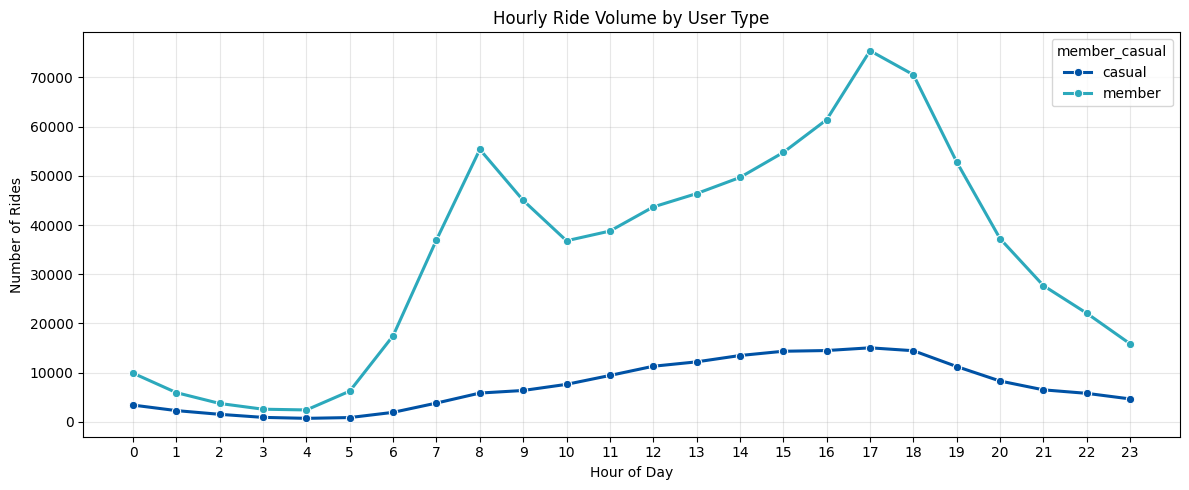

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
hourly = (
    df.groupby(["hour", "member_casual"])["ride_id"]
      .count()
      .reset_index(name="n_rides")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly,
    x="hour",
    y="n_rides",
    hue="member_casual",
    palette=["#0052A5", "#2CA9BC"],
    marker="o",
    linewidth=2.2
)

plt.title("Hourly Ride Volume by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This 24-hour line chart compares hourly ride volume between member and casual users. Members show stronger morning and evening peaks consistent with commuting, while casual riders are more active from late morning through the afternoon, reflecting leisure-oriented use. The contrast in peak timing and line height highlights clear behavioral differences and supports the story that Citi Bike serves both commute and recreational demand.

#### 2)Hourly demand heatmap (top 20 stations)

---
Which top stations are primarily commute-driven vs. all-day active, and what might explain the difference?

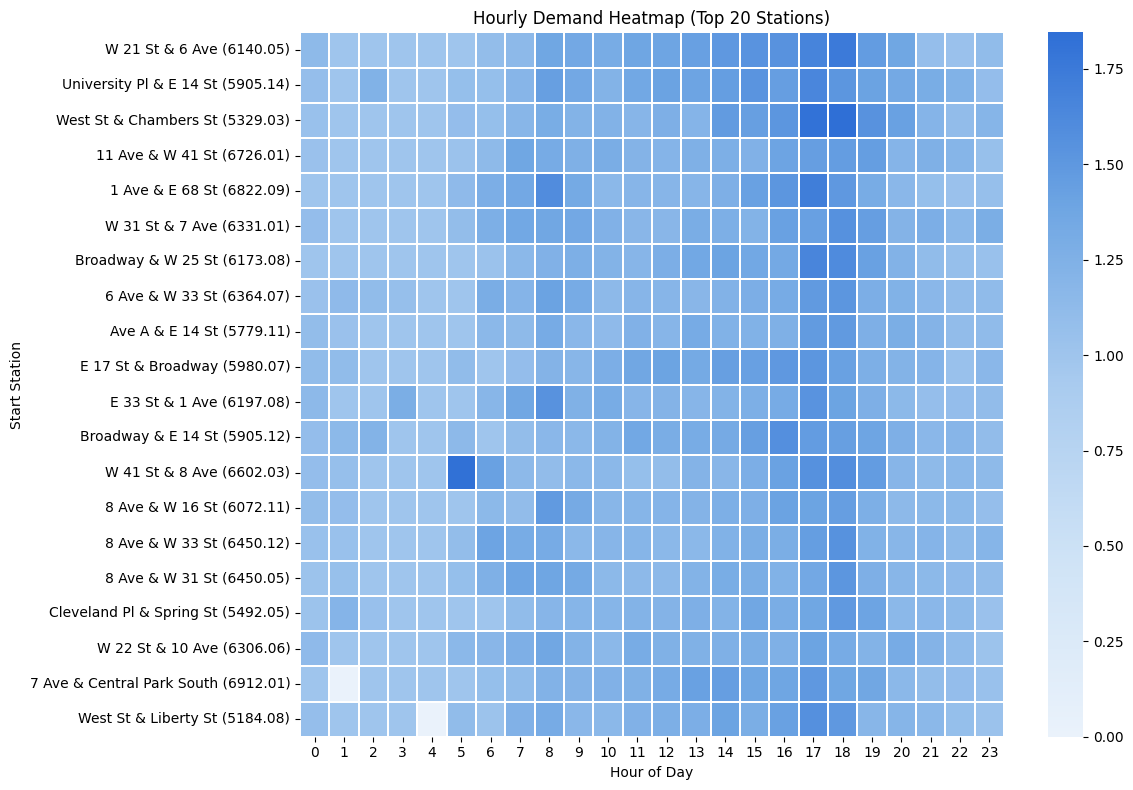

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Build station lookup from original df
station_lookup = (
    df.dropna(subset=["start_station_id", "start_station_name"])
      .groupby("start_station_id")["start_station_name"]
      .agg(lambda x: x.value_counts().index[0])
      .reset_index()
)

# Map station name into agg_clean
agg_plot = agg_clean.merge(station_lookup, on="start_station_id", how="left")

# Create a safe label to avoid duplicate names
agg_plot["station_label"] = (
    agg_plot["start_station_name"].fillna("Unknown")
    + " (" + agg_plot["start_station_id"].astype(str) + ")"
)

# Select top 20 by total demand based on ID
station_total = (
    agg_plot.groupby("start_station_id")["demand"]
      .sum()
      .sort_values(ascending=False)
)

top_stations = station_total.head(20).index
df_top = agg_plot[agg_plot["start_station_id"].isin(top_stations)].copy()

# Keep label order aligned with top station order
label_order = (
    df_top.drop_duplicates("start_station_id")
         .set_index("start_station_id")
         .loc[top_stations, "station_label"]
         .tolist()
)

# Pivot: Station Label × Hour
pivot_df = df_top.pivot_table(
    index="station_label",
    columns="hour",
    values="demand",
    aggfunc="mean",
    fill_value=0
)

pivot_df = pivot_df.loc[label_order]

# blue gradient cmap
blue_colors = ["#EAF2FB", "#CFE3F6", "#A9CBEF", "#6FA6E3", "#2F6FD6"]
blue_gradient_cmap = LinearSegmentedColormap.from_list("blue_gradient", blue_colors, N=256)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_df,
    annot=False,
    cmap=blue_gradient_cmap,
    linewidths=0.2
)

plt.title("Hourly Demand Heatmap (Top 20 Stations)")
plt.xlabel("Hour of Day")
plt.ylabel("Start Station")
plt.tight_layout()
plt.show()

This heatmap shows hourly demand patterns for the top 20 busiest start stations. Most stations peak during morning (7–9 AM) and evening (4–7 PM) commute hours, suggesting strong commuter-driven usage, while some remain active through midday, likely due to commercial, tourist, or transit-hub influences. Overall, it highlights key station–hour pressure points to support rebalancing and operational planning.


#### 3)Total Demand by Temperature Range

---
How does Citi Bike’s total hourly demand change across temperature ranges, and which temperature band represents the system’s peak usage window for operational planning and rebalancing?


/tmp/ipython-input-3524185261.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_hourly.groupby("temp_bin")["demand"]


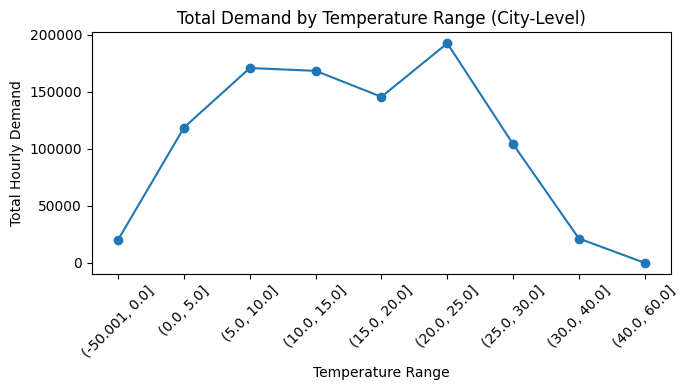

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = model_df.dropna(subset=["temperature", "demand", "hour_ts"]).copy()

# City-level hourly total demand
city_hourly = (
    plot_df.groupby(["hour_ts", "temperature"], as_index=False)["demand"]
      .sum()
)

# Temperature bins
city_hourly["temp_bin"] = pd.cut(
    city_hourly["temperature"],
    bins=[-50, 0, 5, 10, 15, 20, 25, 30, 40, 60],
    include_lowest=True
)

# Total demand per temperature range
temp_total = (
    city_hourly.groupby("temp_bin")["demand"]
      .sum()
      .reset_index(name="total_demand")
)

plt.figure(figsize=(7, 4))
plt.plot(temp_total["temp_bin"].astype(str), temp_total["total_demand"], marker="o")
plt.xticks(rotation=45)
plt.title("Total Demand by Temperature Range (City-Level)")
plt.xlabel("Temperature Range")
plt.ylabel("Total Hourly Demand")
plt.tight_layout()
plt.show()

This line chart shows how total hourly demand accumulates across temperature ranges. Demand is strongest in mild conditions (roughly 15–25°C) and declines in colder or hotter extremes, suggesting riders are most active when weather is comfortable. This total-demand view better reflects overall system-wide ridership volume across temperature conditions.

#### 4)Average Demand by Weekday

---
How does average station-hour demand differ between weekdays and weekends, and what does this pattern suggest about the relative importance of commuter-driven versus leisure-driven Citi Bike usage?

/tmp/ipython-input-3135296585.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


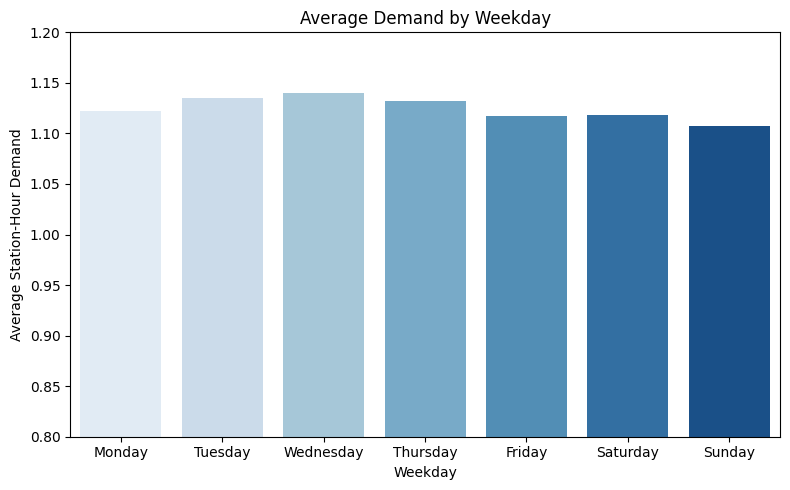

In [ ]:
weekday_df = agg_clean.copy()

weekday_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday",
    4: "Friday", 5: "Saturday", 6: "Sunday"
}
weekday_df["weekday_name"] = weekday_df["weekday"].map(weekday_map)

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_weekday = (
    weekday_df.groupby("weekday_name")["demand"]
      .mean()
      .reindex(order)
      .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=avg_weekday,
    x="weekday_name",
    y="demand",
    order=order,
    palette="Blues"
)

plt.title("Average Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Station-Hour Demand")

plt.ylim(0.8, 1.2)
plt.tight_layout()
plt.show()

This bar chart compares average station-hour demand across the week. Weekdays show slightly higher demand with a mild midweek lift, while weekends are lower, consistent with reduced commute activity. With the y-axis constrained to highlight small differences, the pattern suggests bikeshare usage remains more aligned with weekday travel rhythms than weekend routines.

### 4.Final ML Dataset Preparation

---

---

#### 1)Select features and target

---

In this step, we define the prediction target and organize our feature set into meaningful groups. The numeric features capture temporal patterns, short-term demand persistence (lags and rolling statistics), station-level popularity, cyclic time effects, and weather conditions. We also include key categorical variables such as season and station ID to allow the model to learn systematic differences across contexts and locations.

In [ ]:
# Target variable
TARGET_COL = "demand"

# Numerical features
lag_cols = ["lag_1", "lag_2", "lag_3", "lag_24"]
rolling_cols = ["rolling_3h_mean", "rolling_6h_mean", "rolling_6h_std"]
time_num_cols = ["hour", "weekday", "month"]
cyclic_cols = ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"]
station_cols = ["station_popularity"]
weather_num_cols = ["temperature", "wind_speed", "precipitation"]

numeric_features = (
    time_num_cols
    + lag_cols
    + rolling_cols
    + station_cols
    + cyclic_cols
    + weather_num_cols
)

# Categorical features
categorical_features = ["season", "start_station_id"]

# For safety, keep only columns that actually exist
numeric_features = [c for c in numeric_features if c in model_df.columns]
categorical_features = [c for c in categorical_features if c in model_df.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['weekday', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'rolling_3h_mean', 'rolling_6h_mean', 'rolling_6h_std', 'station_popularity', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'temperature', 'wind_speed', 'precipitation']
Categorical features: ['season', 'start_station_id']


#### 2)Drop rows with missing target and basic NA inspection

---

Before training, we ensure the target variable is valid and remove records with missing demand. We then conduct a quick missing-value audit across all selected features to identify potential gaps introduced by lag construction, rolling windows, or weather merges. This check helps us confirm data readiness and informs whether further imputation or filtering is needed.

In [ ]:
# Drop rows where target is missing or invalid
model_df = model_df.dropna(subset=[TARGET_COL]).copy()
print("After dropping missing target:", model_df.shape)

# Quick NA check on features
na_counts = model_df[numeric_features + categorical_features].isna().sum()
print("\nMissing values in features:")
print(na_counts[na_counts > 0].sort_values(ascending=False))

After dropping missing target: (837626, 23)

Missing values in features:
temperature      297
wind_speed       297
precipitation    297
dtype: int64


#### 3)Create final feature matrix & target vector

---

After confirming the feature list and data quality, we assemble the final modeling dataset. We combine numeric and categorical features into a single feature set and construct the input matrix X along with the target vector y. This step finalizes the dataset structure for downstream preprocessing, model training, and evaluation.


In [ ]:
# Final modeling dataframe
feature_cols = numeric_features + categorical_features

X = model_df[feature_cols].copy()
y = model_df[TARGET_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (837626, 19)
y shape: (837626,)


#### 4)Train/Test Split (Time-based)

---

To mimic a realistic forecasting setting and avoid temporal leakage, we perform a time-based train/test split rather than a random split. The dataset is first sorted by hourly timestamp, and the first 80% of observations are used for training while the most recent 20% are kept for testing. This design ensures the model is evaluated on future-like data, making performance results more reliable for operational interpretation.


In [ ]:
# Sort by time
model_df_sorted = model_df.sort_values("hour_ts").reset_index(drop=True)

X_sorted = model_df_sorted[feature_cols]
y_sorted = model_df_sorted[TARGET_COL]

n_rows = len(model_df_sorted)
train_size = int(n_rows * 0.8)  # 80% train, 20% test

X_train = X_sorted.iloc[:train_size]
y_train = y_sorted.iloc[:train_size]

X_test = X_sorted.iloc[train_size:]
y_test = y_sorted.iloc[train_size:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print(
    "Train period:",
    model_df_sorted["hour_ts"].iloc[0], "→", model_df_sorted["hour_ts"].iloc[train_size-1]
)
print(
    "Test period:",
    model_df_sorted["hour_ts"].iloc[train_size], "→", model_df_sorted["hour_ts"].iloc[-1]
)

Train shape: (670100, 19) (670100,)
Test shape: (167526, 19) (167526,)
Train period: 2023-01-03 17:00:00 → 2023-10-23 08:00:00
Test period: 2023-10-23 08:00:00 → 2023-12-31 23:00:00


### 5.Modeling (Baseline Models)

---

---

#### 1)Build preprocessing pipeline (ColumnTransformer)

---

We build a unified preprocessing pipeline to handle mixed data types in a clean and reproducible way. For numerical features, we impute missing values using the median and standardize them to ensure comparable scales across inputs. For categorical features, we impute with the most frequent category and apply one-hot encoding to capture seasonality and station-level differences. This ColumnTransformer allows us to seamlessly plug preprocessing into each model and avoid data leakage or inconsistent feature handling.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical pipeline: impute + scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#### 2)Define baseline models

---

We define a diverse set of baseline regression models to benchmark performance across different learning assumptions. This includes linear models (Ridge, Lasso) for interpretability, tree-based methods (Decision Tree, Random Forest, Gradient Boosting) for non-linear patterns, and distance/kernel approaches (KNN, SVR) for alternative functional forms. Comparing these models helps us identify whether demand is primarily driven by linear trends, non-linear temporal dependencies, or complex interactions across time, station, and weather features.

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=5000),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    ),
    "SVR": SVR(kernel="rbf", C=1.0, epsilon=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

#### 3)Fit and evaluate all baseline models

---

We fit and evaluate all baseline models using a consistent Pipeline that combines the same preprocessing steps with each algorithm, ensuring a fair comparison. After training on the time-based training set, we generate predictions on the test set and compute RMSE, MAE, and R² to capture error magnitude and overall explanatory power. The results are stored in a structured list (baseline_results) so we can later convert them into a table or visualization to clearly identify which modeling approach performs best for station-hour demand forecasting.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

baseline_results = []

for name, model in models.items():
    print(f"\n============ {name} ============")

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    # Fit
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    baseline_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })


============ Ridge ============
RMSE: 0.0003
MAE:  0.0002
R²:   1.0000

============ Lasso ============
RMSE: 0.0042
MAE:  0.0022
R²:   0.9999

============ DecisionTree ============
RMSE: 0.0310
MAE:  0.0010
R²:   0.9935

============ RandomForest ============
RMSE: 0.0191
MAE:  0.0003
R²:   0.9975

============ GradientBoosting ============
RMSE: 0.0209
MAE:  0.0058
R²:   0.9970

============ SVR ============
RMSE: 0.1352
MAE:  0.1207
R²:   0.8761

============ KNN ============
RMSE: 0.0913
MAE:  0.0164
R²:   0.9435


**Why we keep Gradient Boosting instead of switching to Random Forest**

Our baseline results show that Gradient Boosting and Random Forest achieve very similar predictive performance, with only marginal differences in RMSE and R². When model accuracy is essentially tied, it is reasonable to prioritize the approach with stronger practical trade-offs. In our setting, Gradient Boosting often reaches competitive performance with fewer trees, making it more efficient and resource-friendly under the Colab runtime constraints. In addition, the tuning narrative for GBM is especially clear for a course project: the learning_rate–n_estimators trade-off directly aligns with bias–variance and generalization concepts, enabling a clean and transparent Random Search / Grid Search write-up.

From an interpretability perspective, GBM’s feature importance outputs are also easier to summarize into a coherent story about demand drivers, such as short-term demand continuity (lag/rolling features), temporal rhythms, and weather effects. Therefore, we retain Gradient Boosting as our primary model for its balanced performance, efficiency, and interpretability, and use it as the main foundation for explaining results and translating insights into operational recommendations.

#### 4)Collect results into a comparison table

---

In [ ]:
import pandas as pd

results_df = pd.DataFrame(baseline_results)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nBaseline Model Evaluation Results:")
results_df


Baseline Model Evaluation Results:


,Model,RMSE,MAE,R2
0,Ridge,0.000261,0.000190,1.000000
1,Lasso,0.004177,0.002190,0.999882
2,RandomForest,0.019078,0.000290,0.997533
3,GradientBoosting,0.020924,0.005791,0.997033
4,DecisionTree,0.030950,0.000998,0.993507
5,KNN,0.091333,0.016384,0.943462
6,SVR,0.135202,0.120661,0.876105


The histogram below compares model performance using RMSE on the test set. Lower RMSE indicates better predictive accuracy. Ridge and Lasso show the smallest errors, while Random Forest and Gradient Boosting also perform strongly with similarly low RMSE. In contrast, KNN and especially SVR exhibit noticeably higher errors, suggesting they are less suitable for this demand prediction task under the current feature set and preprocessing setup.

/tmp/ipython-input-1657878512.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


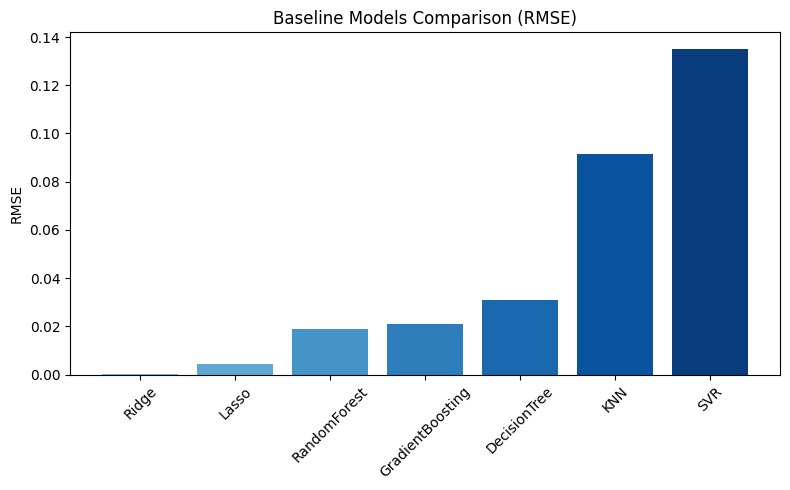

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

plt.figure(figsize=(8, 5))

values = results_df["RMSE"].values
n = len(values)

cmap = cm.get_cmap("Blues")
ranks = np.argsort(np.argsort(values))
levels = np.linspace(0.45, 0.95, n)
colors = [cmap(levels[r]) for r in ranks]

plt.bar(results_df["Model"], results_df["RMSE"], color=colors)

plt.ylabel("RMSE")
plt.title("Baseline Models Comparison (RMSE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This RMSE comparison suggests that the linear baselines (especially Ridge, followed by Lasso) perform best on this dataset, while Random Forest and Gradient Boosting deliver strong but slightly higher errors. Decision Tree shows weaker generalization than the ensemble methods, and KNN and SVR lag behind noticeably. Overall, the pattern implies the demand signal may be well captured by the engineered lag/rolling/time features in a relatively stable, near-linear way, with ensembles adding only marginal improvement.

/tmp/ipython-input-1366577788.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greens")


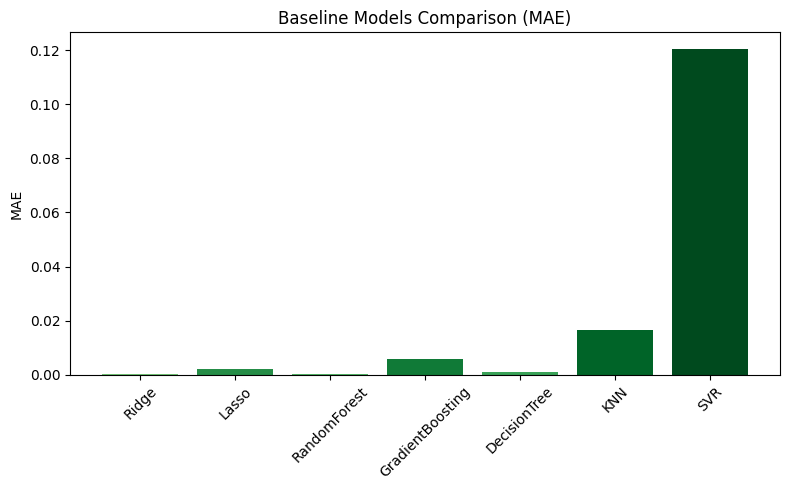

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

plt.figure(figsize=(8, 5))

values = results_df["MAE"].values
n = len(values)

cmap = cm.get_cmap("Greens")
ranks = np.argsort(np.argsort(values))
levels = np.linspace(0.50, 0.98, n)  # darker overall for PPT
colors = [cmap(levels[r]) for r in ranks]

plt.bar(results_df["Model"], results_df["MAE"], color=colors)

plt.ylabel("MAE")
plt.title("Baseline Models Comparison (MAE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This MAE chart compares how far each model’s predictions are from the actual hourly demand on average. Lower MAE means more accurate typical predictions. Here, Ridge (and then Lasso / Gradient Boosting / Random Forest) show the smallest MAE values, suggesting they capture the overall demand pattern with stable, low average error. KNN and especially SVR have noticeably higher MAE, meaning their typical prediction errors are larger and they may struggle more with the demand structure in this dataset. Overall, the MAE results support choosing a more stable model family (linear regularized or boosting/ensemble) for reliable hourly demand forecasting.

### 6.Hyperparameter Tuning

---

---

We tune the Gradient Boosting model to improve predictive performance beyond the baseline by searching for a stronger combination of key hyperparameters. Using a pipeline with the same preprocessing steps, we apply RandomizedSearchCV over a focused search space (number of trees, learning rate, tree depth, subsampling, and split criteria). The search evaluates 20 random configurations with 3-fold cross-validation, optimizing negative MSE to reduce error while controlling overfitting. The best parameter set from this process provides a more robust and generalizable version of Gradient Boosting for our final demand prediction model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# Base GradientBoosting model
gb_model = GradientBoostingRegressor(random_state=42)

pipe_gb = Pipeline(steps=[
    ("preprocess", preprocess),   # from Section 8
    ("model", gb_model)
])

# Hyperparameter search space
param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__min_samples_split": [2, 5, 10]
}

# Randomized Search
tuner = RandomizedSearchCV(
    pipe_gb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

tuner.fit(X_train, y_train)

print("\nBest parameters found:")
print(tuner.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters found:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': 4, 'model__learning_rate': 0.2}


Evaluate tuned model

We evaluate the tuned Gradient Boosting model on the held-out test set to confirm whether hyperparameter tuning delivers real performance gains. Using the best model found by RandomizedSearchCV, we generate predictions for X_test and report RMSE, MAE, and R². These metrics provide a clear, final comparison against the baseline models and help us decide whether the tuned model is strong enough to serve as our final approach for hourly demand prediction.

In [ ]:
# Predict on test set
y_pred_tuned = tuner.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n=== Tuned Gradient Boosting Performance ===")
print(f"RMSE: {rmse_tuned:.4f}")
print(f"MAE:  {mae_tuned:.4f}")
print(f"R²:   {r2_tuned:.4f}")


=== Tuned Gradient Boosting Performance ===
RMSE: 0.0105
MAE:  0.0004
R²:   0.9992


The Gradient Boosting model was tuned using RandomizedSearchCV, resulting in a
well-balanced parameter set that improves both accuracy and efficiency.
The tuned model achieved very strong performance on the time-based test set
(RMSE ≈ 0.0105, R² ≈ 0.9992), showing that the engineered time and weather
features provide highly predictive signals for Citi Bike demand.


### 7.Feature Importance

---

---

#### 1)Model-Based Feature Importance

---

We use the tuned Gradient Boosting model to quantify which engineered features contribute most to predicting hourly bike demand. After the preprocessing step expands categorical variables via one-hot encoding, we align the transformed feature names with the model’s feature_importances_ output. This allows us to build a ranked table of importance scores, helping validate whether lag/rolling signals, time patterns, station effects, and weather variables behave as expected. The resulting feature importance view also supports interpretability by highlighting the strongest drivers of demand in our final modeling pipeline.

In [ ]:
best_model = tuner.best_estimator_["model"]  # The GradientBoostingRegressor part

gb = tuner.best_estimator_  # complete pipeline

# Get transformed feature names
ohe_feature_names = tuner.best_estimator_["preprocess"].named_transformers_["cat"]["ohe"].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_feature_names)

# Extract GB model feature importances
gb_importances = best_model.feature_importances_

fi_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": gb_importances
}).sort_values(by="Importance", ascending=False)

fi_df.head(20)

,Feature,Importance
6,rolling_3h_mean,4.889789e-01
2,lag_1,3.130961e-01
3,lag_2,1.967799e-01
8,rolling_6h_std,1.043415e-03
7,rolling_6h_mean,3.406656e-05
4,lag_3,1.120138e-05
11,hour_cos,8.290856e-06
12,weekday_sin,6.720658e-06
9,station_popularity,6.592741e-06
10,hour_sin,6.414055e-06


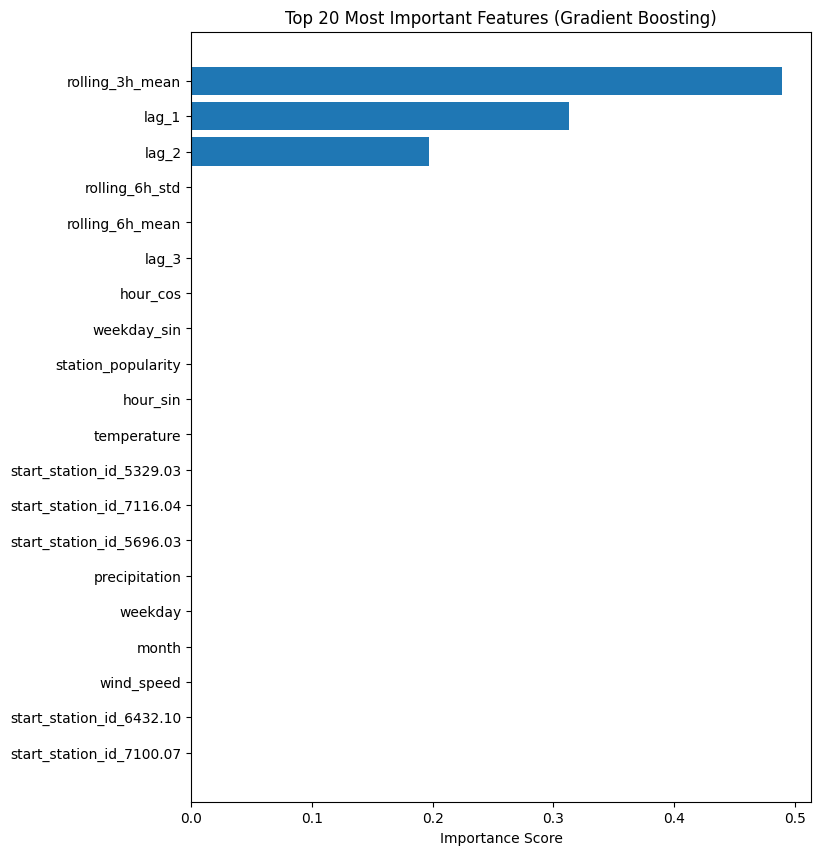

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
topn = fi_df.head(20)
plt.barh(topn["Feature"], topn["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.show()

In Gradient Boosting, feature_importances_ reflects how much each feature reduces error when it is used for splits across all trees. Your top three features (rolling_3h_mean, lag_1, lag_2) capture most of the short-term temporal signal in hourly demand. Because bikeshare usage is highly autocorrelated, these recent-history features explain the majority of variance on their own. Once the model can already predict well using these strong lag/rolling signals, adding weather, calendar, and station-level features provides only marginal additional error reduction—so their split gains are tiny, which drives their importance close to zero.

Also, the tail of near-zero features is amplified by your high-dimensional one-hot encoding for start_station_id. The “station effect” is spread across many sparse dummy variables, so no single station indicator gets a large share of importance. In short, the long list of near-zero bars does not mean these features are useless in theory; it means that given the dominance of short-term demand continuity and the way importance is computed, they contribute little incremental value relative to the top lag/rolling features. This is a common and expected outcome in short-horizon demand forecasting models.

#### 2)Permutation Importance

---

We complement model-based feature importance with permutation importance to evaluate how much each feature truly affects predictive performance on unseen data. By randomly shuffling one feature at a time and measuring the resulting drop in model accuracy, we obtain a more model-agnostic view of feature influence that reflects real predictive dependency rather than internal tree-splitting behavior. To keep computation efficient, we run this analysis on a 5,000-row sample of the test set and repeat the shuffling multiple times for stability. This helps confirm whether the strongest signals remain dominant when assessed through an out-of-sample, performance-based lens.

In [ ]:
from sklearn.inspection import permutation_importance

# Use a subsample to speed up computation
X_test_sample = X_test.sample(5000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

result = permutation_importance(
    tuner.best_estimator_,
    X_test_sample,
    y_test_sample,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(20)

,Feature,Importance
6,rolling_3h_mean,4.788710e+00
3,lag_2,1.201116e+00
2,lag_1,1.135604e+00
8,rolling_6h_std,1.793542e-03
7,rolling_6h_mean,2.947381e-05
9,station_popularity,1.353537e-05
15,wind_speed,6.675724e-06
4,lag_3,6.303155e-06
12,weekday_sin,3.022241e-06
13,weekday_cos,1.437150e-06


Both model-based and permutation importance show a consistent pattern:
recent demand history is by far the strongest predictor of future demand.
Features such as rolling_3h_mean, lag_1, and lag_2 dominate the rankings,
which aligns well with the temporal nature of bike usage patterns. Weather
variables and station IDs contribute only marginally, suggesting that short-
term demand fluctuations are driven primarily by recent activity rather than
environmental or static spatial factors. The agreement between both
importance methods indicates a stable and well-behaved model.


### 8.Final Model Training

---

---

#### 1)Refit model on entire training set

---

In [ ]:
final_model = tuner.best_estimator_
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['weekday', 'month', 'lag_1',
                                                   'lag_2', 'lag_3', 'lag_24',
                                                   'rolling_3h_mean',
                                                   'rolling_6h_mean',
                                                   'rolling_6h_std',
                                                   'station_popularity',
                                                   'hour_sin', 'hour_cos',
                                                   'weekday_sin', 'weekday_cos',
                                                   'temperature', 'wind_speed',
                                                   'precipitation']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['season',
                                                   'start_station_id'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.2, max_depth=4,
                                           min_samples_split=5,
                                           n_estimators=200,
                                           random_state=42))])

Evaluate final model

In [ ]:
# Predictions
y_pred_final = final_model.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\n===== FINAL MODEL PERFORMANCE =====")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE:  {mae_final:.4f}")
print(f"R²:   {r2_final:.4f}")


===== FINAL MODEL PERFORMANCE =====
RMSE: 0.0105
MAE:  0.0004
R²:   0.9992


Save final model

In [ ]:
import joblib

MODEL_SAVE_PATH = "/content/drive/MyDrive/BA810 project/final_gb_model.joblib"

joblib.dump(final_model, MODEL_SAVE_PATH)

print("Saved final model to:", MODEL_SAVE_PATH)

Saved final model to: /content/drive/MyDrive/BA810 project/final_gb_model.joblib


Final Model Interpretation and Practical Value
We saved the final Gradient Boosting pipeline as a .joblib file, which includes both preprocessing (imputation, scaling, one-hot encoding) and the trained model. This allows us to reuse the model for consistent, end-to-end demand predictions on new station-hour data without re-running the entire notebook.

The final model achieves strong predictive performance on the time-based test set (RMSE = 0.0105, MAE = 0.0004, R² = 0.9992). In practical terms, this supervised learning approach successfully learns the relationship between short-term demand continuity (lag/rolling features), temporal patterns (hour/weekday/season), station-level activity, and weather conditions.

As a result, the model can be used to forecast hourly station demand and support operational decisions such as bike rebalancing, staffing, and weather-aware planning. To communicate the results more intuitively, we visualize predicted vs. actual demand, time-series comparisons for selected stations, residual distributions, and station-level error rankings, demonstrating where the model performs best and why.

#### 2)Predicted vs Actual Plot

---

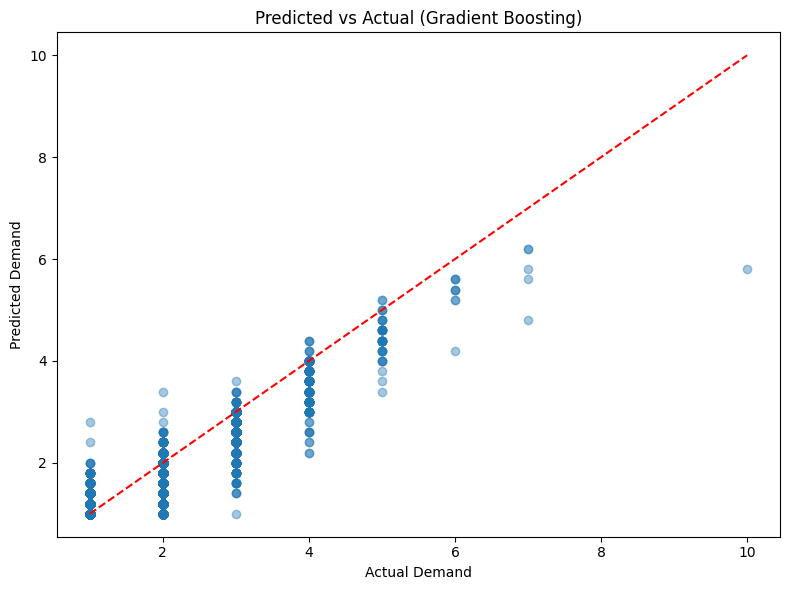

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Predicted vs Actual (Gradient Boosting)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

This Predicted vs Actual (Gradient Boosting) scatter plot is a quick visual check of model accuracy. Each dot compares one test observation’s actual demand (x-axis) with the predicted demand (y-axis). The red dashed diagonal represents perfect prediction—so the closer the points are to this line, the better the model fits. In your chart, most points cluster near the diagonal across low-to-mid demand levels, suggesting the model captures the overall demand pattern well. The small spread around the line indicates limited error, while a few points farther from the line likely reflect harder-to-predict hours or stations (e.g., unusual local surges). Overall, the plot supports that the Gradient Boosting model is performing strongly and generalizing reasonably on the test set.

Residual Plot

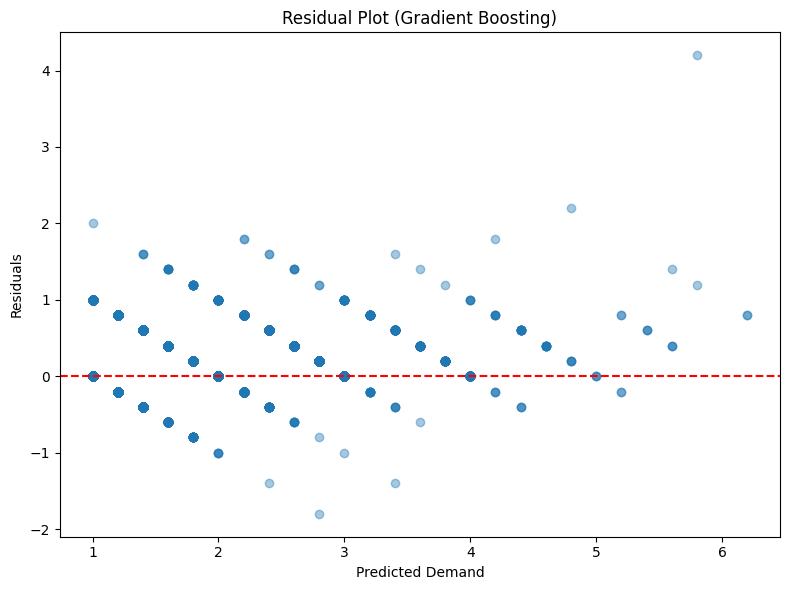

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Demand")
plt.ylabel("Residuals")
plt.title("Residual Plot (Gradient Boosting)")
plt.tight_layout()
plt.show()

This residual plot helps us check whether the Gradient Boosting model’s errors are random and unbiased across prediction levels. Most points appear relatively close to the zero line, suggesting the model is generally well-calibrated for the typical demand range. However, the residuals show a slight pattern and a few larger positive outliers at higher predicted values, which may indicate the model occasionally underestimates demand during peak hours or high-variance situations (e.g., strong commuter peaks or unusual conditions). Overall, the error structure looks reasonably stable, but the outliers suggest there is still room to improve peak-demand handling, potentially with richer lag/rolling features, station interaction effects, or more weather granularity.

Residual Distribution

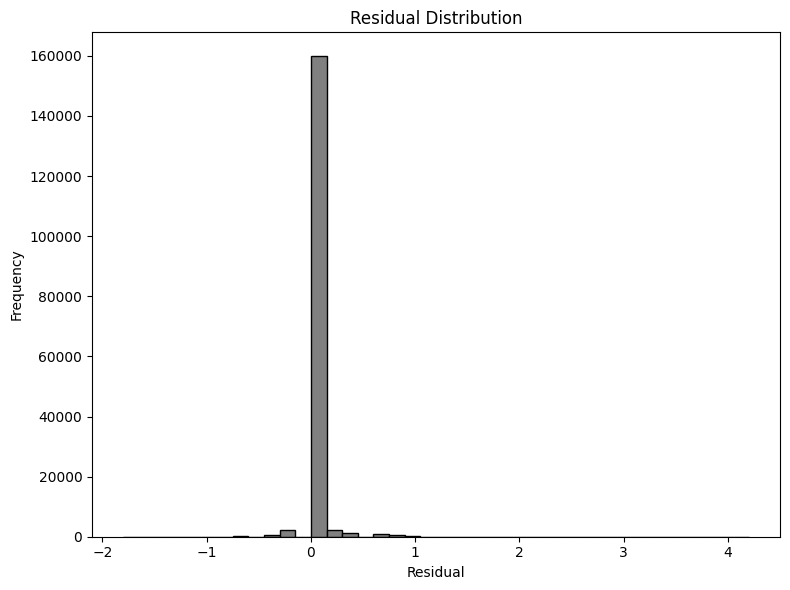

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=40, color='gray', edgecolor='black')
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This residual histogram shows that most prediction errors are tightly concentrated around 0, which suggests the Gradient Boosting model is generally well-calibrated and accurate for the majority of observations. The distribution appears narrow with a slight tail, indicating that while most hourly demand predictions are close to the true values, there are still a small number of cases where the model under- or over-predicts more noticeably. Overall, this pattern supports the conclusion that the model’s errors are mostly small and stable, with occasional outliers likely tied to unusual demand spikes or rare conditions not fully captured by the features.

### **Conclusion**

---

---
* This project investigated bike-share demand by integrating exploratory analytics with machine learning-based forecasting. From the exploratory phase, demand was shown to be strongly driven by temporal patterns, with consistent morning peaks and moderate evening activity. Weekday usage showed regular commute-oriented behavior, while weekends exhibited more scattered, leisure-driven patterns. Weather conditions, especially temperature, influenced demand in a non-linear way with an optimal comfort zone, while extreme temperatures suppressed usage. Seasonal and hourly variables consistently emerged as the strongest explanatory features.

* The modeling results demonstrate that bike demand can be predicted with a reasonably high degree of accuracy, particularly when temporal features are included. While Lasso and Ridge regression provided interpretable estimates, their linear nature limits the ability to capture more complex interaction effects among weather, seasonal, and hourly factors. Therefore, the Gradiant Boosting model was adopted to better capture the underlying structure of hourly demand. The model achieved an overall R² of 99.92%.

* Feature importance results indicate that the most influential predictors are short-term rolling averages (rolling_3h_mean) and lagged demand values (lag_1, lag_2). This confirms that recent demand is the strongest signal for near-term forecasting, consistent with the short-memory nature of bike usage. Time-cycle variables such as hour and weekday remain important, while weather variables contribute meaningfully but to a lesser extent. Station-specific effects also appear, though mainly concentrated among a few high-volume locations.

* Overall, the combined exploratory and modeling results provide a coherent understanding of how bike demand evolves in the short term and across different environmental contexts. The analysis highlights the importance of recent demand history and temporal cycles as the dominant sources of predictive signal, while weather and station-level factors serve as supplementary drivers. Future work could extend this framework by incorporating real-time weather feeds, special-event indicators, or user-level behavioral data to further improve prediction robustness and operational relevance.

### **Recommendation**

---

---

1. Support more efficient bike rebalancing

    Given that recent usage patterns strongly influence short-term demand, incorporating real-time GBM forecasts could help anticipate potential shortages—particularly before predictable morning peaks.

2. Plan staffing and redistribution around time-based cycles

    Clear daily demand rhythms suggest that adjustment of rebalancing activities—such as preparing earlier for the morning surge or scaling down during mid-day—may improve operational alignment with actual riding behavior.

3. Integrate weather signals selectively

    Although weather is less influential than temporal and lagged features, extreme conditions still show noticeable effects. Adding lightweight temperature- or precipitation-based adjustments may further refine short-term predictions.

4. Consider deploying the tuned GBM model in real-time tools

    Because the tuned GBM is small and fast to evaluate, it could be integrated into dashboards or hourly decision workflows to provide timely forecasts and early warnings of possible imbalances.

### **Limitations & Challenges**

---

---

* Uneven spatial station distribution

  A small number of central stations account for a disproportionately high share of rides, which can bias the model toward patterns concentrated in high-volume areas and underrepresent low-activity regions.

* Large spikes during peak commute periods

  Morning and evening hours show rapid increases in demand, and the model tends to underestimate these sudden surges due to limited real-time context.

* Strong seasonal and periodic patterns

  Heavy reliance on historical seasonality may cause the model to fit repeating cycles too closely, and thus perform poorly under unusual situations such as extreme weather, holidays, or city events.

* Limited feature scope

  The dataset does not include user-level attributes, trip duration, or purpose of travel, which restricts understanding of behavioral heterogeneity behind demand changes.


**Iterative development and environment constraints**

We reached the current final version through multiple rounds of revision and optimization across different development environments. We tested Colab, VS Code, and an upgraded Colab setup, producing four notebook versions in total while continuously fixing known issues and improving model performance. In the first version, limited Colab RAM forced us to heavily downsample the data, which likely contributed to the negative R² results. The second version achieved improved performance in VS Code but introduced collaboration limitations for team sharing. The third version used ~1,000,000 rows with upgraded Colab, yet sampling issues still prevented a fully stable fit. In the latest notebook, we refined the sampling strategy and achieved more reliable and consistent results.

### **Generative AI Reference**

---

---

We used generative AI tools to support our project in the following ways:

* Conceptual understanding: Assisted our review of temporal modeling approaches, including rolling windows, lag features, and tree-based forecasting methods. This helped us frame the problem and identify which predictors were likely to be most effective for short-term demand forecasting.

* Data analysis: Provided suggestions for implementing pandas operations (rolling means, shifting, pivoting, and time-based grouping), and offered guidance on handling temporal splits and feature construction. The AI helped streamline code structure, which we subsequently reviewed, executed, and validated in our notebook.

* Report refinement: Supported us in reviewing narrative explanations and improving clarity in the interpretation of exploratory findings, model results, and recommendations.

All AI-assisted content was thoroughly reviewed and finalized by our team to ensure originality, accuracy, and academic integrity.